In [29]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [30]:
# Download sample images

!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=17osoadBvt1LyZI1qDg_DSrUWHQTSfIPh' -O provided_corners.npy
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1o4rgHOHhS0heowX8DX4Fu0k6IPAyzNzF' -O provided_source.jpg
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=15Zxo1jv_wfFkkqVbZt37oSJJDAu86kpV' -O provided_target.jpg
# For the provided source image, credit to: https://www.quantamagazine.org/the-computing-pioneer-helping-ai-see-20231024/



--2026-02-11 06:14:12--  https://docs.google.com/uc?export=download&id=17osoadBvt1LyZI1qDg_DSrUWHQTSfIPh
Resolving docs.google.com (docs.google.com)... 142.251.2.101, 142.251.2.139, 142.251.2.113, ...
Connecting to docs.google.com (docs.google.com)|142.251.2.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=17osoadBvt1LyZI1qDg_DSrUWHQTSfIPh&export=download [following]
--2026-02-11 06:14:12--  https://drive.usercontent.google.com/download?id=17osoadBvt1LyZI1qDg_DSrUWHQTSfIPh&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 640 [application/octet-stream]
Saving to: ‘provided_corners.npy’

provided_corners.np 100%[===================>]     640  --.-KB/s    in 0s   

Source shape: (968, 1720, 3)
Target shape: (1512, 2016, 3)
v (corners) shape: (2, 32)



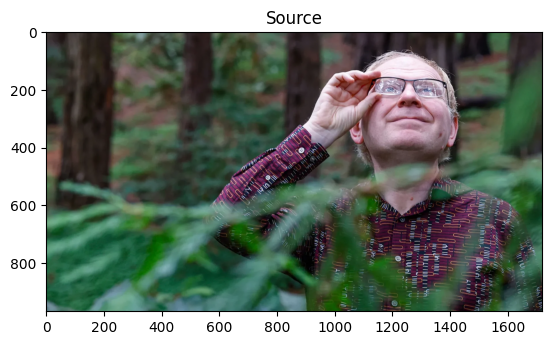

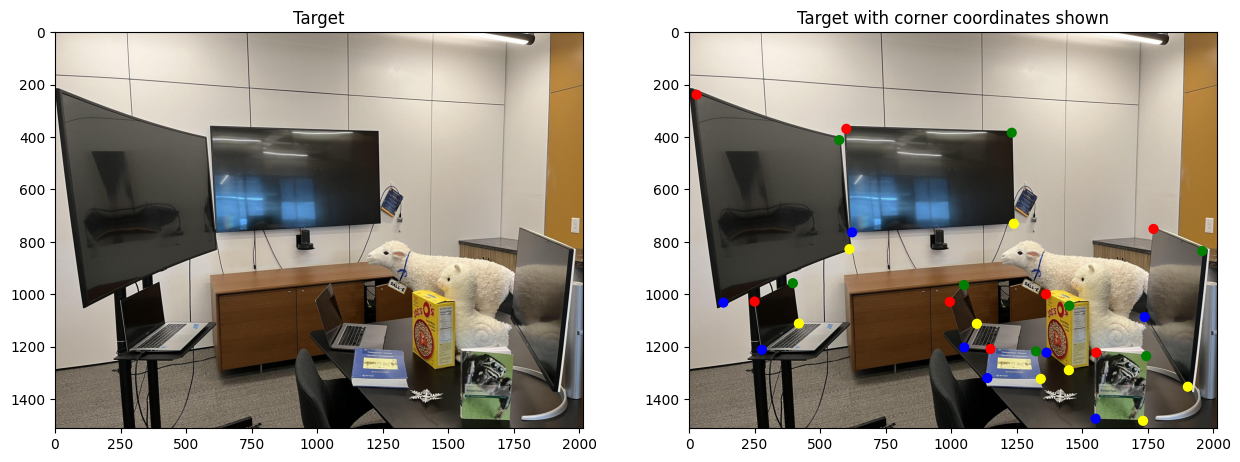

In [31]:
def reshape(x):
  """
  x: size N_locations x 4 x 2, where N_locations is the number of locations to map to in the target image.
  Return x reshaped into 2x(4*N_locations),
  I.e., rows 0-3 in the output are the corners of the first location in the target image, rows 4-7 are the second, etc.
  """
  assert x.ndim == 3
  assert x.shape[1] == 4, x.shape[2] == 2
  y = np.zeros((2, x.shape[0]*4))

  y[0,:] = x[:,:,0].flatten()
  y[1,:] = x[:,:,1].flatten()

  return y



# Load source & target images into numpy arrays
source = np.array(Image.open('provided_source.jpg'))[:,:,:3]
target = np.array(Image.open('provided_target.jpg'))[:,:,:3]
print(f'Source shape: {source.shape}')
print(f'Target shape: {target.shape}')


# Load coordinates in target image.
# Size in file is N_locations x 4 x 2, each row is in order: top-left, top-right, bottom-left, bottom-right,
# where N_locations is the number of locations in the target image that the source image should be mapped to
v = np.load('provided_corners.npy')
v = np.round(v).astype(int)
v = reshape(v)
print(f'v (corners) shape: {v.shape}')
print()

# Display images
plt.imshow(source)
plt.title('Source')
plt.show()
print()

fig, ax = plt.subplots(1,2, figsize=(15,10))
ax[0].set_title('Target')
ax[0].imshow(target)

ax[1].set_title('Target with corner coordinates shown')
ax[1].imshow(target)

corner_colors = ['red','green','blue','yellow']
for i in range(int(v.shape[1]/4)):
  ax[1].scatter(v[1, i*4:(i*4)+4], v[0, i*4:(i*4)+4], s=40, c=corner_colors)

plt.show()



In [32]:
def affine_solve(u, v):
    # u, v: 2 x N
    N = u.shape[1]

    A = np.zeros((2*N, 6))
    b = np.zeros((2*N,))

    for i in range(N):
        x, y = u[0, i], u[1, i]
        xp, yp = v[0, i], v[1, i]

        A[2*i]   = [x, y, 1, 0, 0, 0]
        A[2*i+1] = [0, 0, 0, x, y, 1]

        b[2*i]   = xp
        b[2*i+1] = yp

    params = np.linalg.solve(A.T @ A, A.T @ b)

    H = np.array([
        [params[0], params[1], params[2]],
        [params[3], params[4], params[5]],
        [0,         0,         1]
    ])

    return H



def homography_solve(u, v):
    # u, v: 2 x N
    N = u.shape[1]

    A = np.zeros((2*N, 8))
    b = np.zeros((2*N,))

    for i in range(N):
        x, y = u[0, i], u[1, i]
        xp, yp = v[0, i], v[1, i]

        A[2*i]   = [x, y, 1, 0, 0, 0, -x*xp, -y*xp]
        A[2*i+1] = [0, 0, 0, x, y, 1, -x*yp, -y*yp]

        b[2*i]   = xp
        b[2*i+1] = yp

    params = np.linalg.solve(A.T @ A, A.T @ b)

    H = np.array([
        [params[0], params[1], params[2]],
        [params[3], params[4], params[5]],
        [params[6], params[7], 1]
    ])

    return H



def do_transform(u, H):
    # u: 2 x N
    N = u.shape[1]

    u_h = np.vstack([u, np.ones((1, N))])  # 3 x N
    v_h = H @ u_h                          # 3 x N

    v = v_h[:2] / v_h[2]

    return v





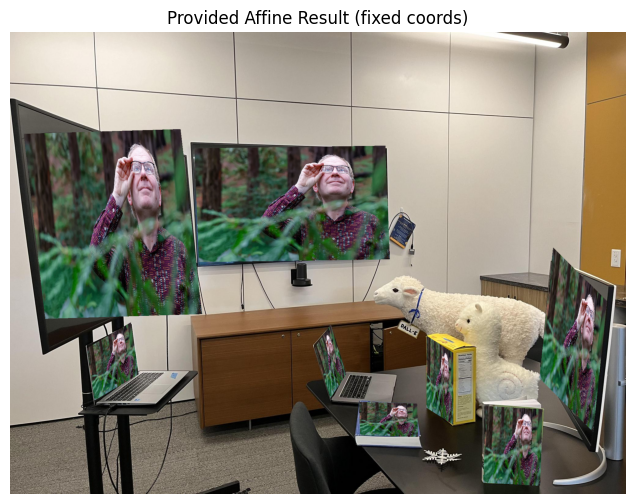

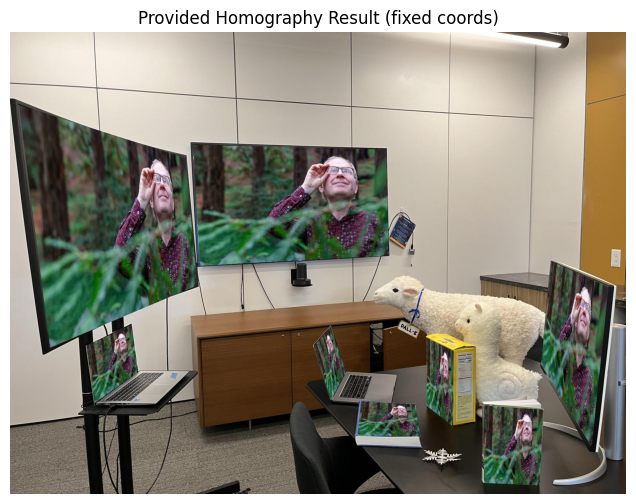

In [33]:
# Perform affine & homography transforms for provided source & target pair,
# as well as a source & target pair of your choosing.

def get_source_corners(img):
    h, w = img.shape[:2]
    return np.array([
        [0,     w-1,   0,     w-1],
        [0,     0,     h-1,   h-1]
    ])

def paste_transformed(source, target, H):
    h_s, w_s = source.shape[:2]
    h_t, w_t = target.shape[:2]

    ys, xs = np.meshgrid(np.arange(h_s), np.arange(w_s), indexing='ij')
    pts = np.vstack([xs.flatten(), ys.flatten()])  # 2 x N

    pts_t = do_transform(pts, H)
    xt, yt = np.round(pts_t).astype(int)

    valid = (
        (xt >= 0) & (xt < w_t) &
        (yt >= 0) & (yt < h_t)
    )

    target_copy = target.copy()
    target_copy[yt[valid], xt[valid]] = source[
        ys.flatten()[valid], xs.flatten()[valid]
    ]

    return target_copy


# -------- Affine (provided) --------
u = get_source_corners(source)
out_affine = target.copy()

for i in range(v.shape[1] // 4):
    v_i = v[[1, 0], i*4:(i+1)*4]   # ← 关键修复
    H_aff = affine_solve(u, v_i)
    out_affine = paste_transformed(source, out_affine, H_aff)

plt.figure(figsize=(10, 6))
plt.imshow(out_affine)
plt.title("Provided Affine Result (fixed coords)")
plt.axis("off")
plt.show()



# -------- Homography (provided) --------
out_homo = target.copy()

for i in range(v.shape[1] // 4):
    v_i = v[[1, 0], i*4:(i+1)*4]   # ← 同样只改这一行
    H_h = homography_solve(u, v_i)
    out_homo = paste_transformed(source, out_homo, H_h)

plt.figure(figsize=(10, 6))
plt.imshow(out_homo)
plt.title("Provided Homography Result (fixed coords)")
plt.axis("off")
plt.show()


In [6]:
from google.colab import files

uploaded = files.upload()


Saving my_source.jpeg to my_source.jpeg
Saving my_target.jpeg to my_target.jpeg


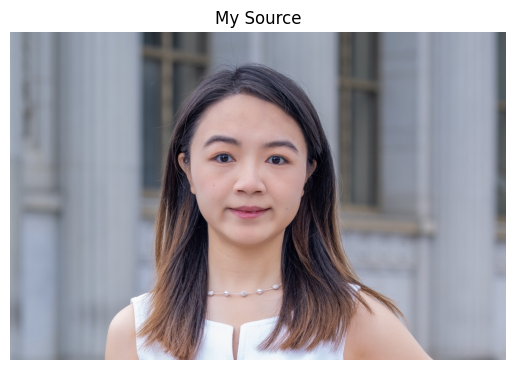

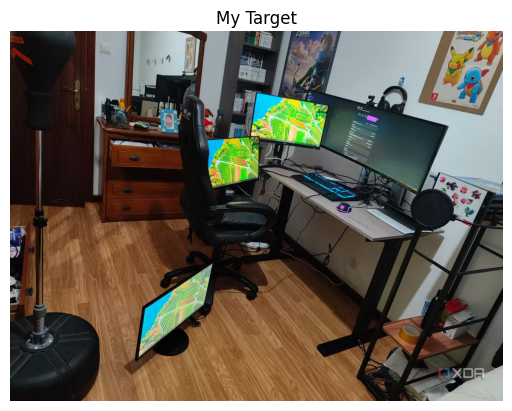

(680, 1028, 3)
(1238, 1650, 3)


In [34]:
from PIL import Image
import numpy as np

my_source = np.array(Image.open("my_source.jpeg"))[:, :, :3]
my_target = np.array(Image.open("my_target.jpeg"))[:, :, :3]

plt.imshow(my_source)
plt.title("My Source")
plt.axis("off")
plt.show()

plt.imshow(my_target)
plt.title("My Target")
plt.axis("off")
plt.show()

print(my_source.shape)
print(my_target.shape)

In [35]:
v_my = np.array([
    [440, 683, 425, 654, 658, 829, 664, 835, 827, 1064,
     803, 1033, 1088, 1470, 1047, 1359, 504, 558, 508, 562],

    [924, 775, 1104, 919, 369, 353, 528, 498, 210, 252,
     350, 397, 225, 330, 386, 547, 266, 270, 343, 343]
])

print(v_my.shape)


(2, 20)


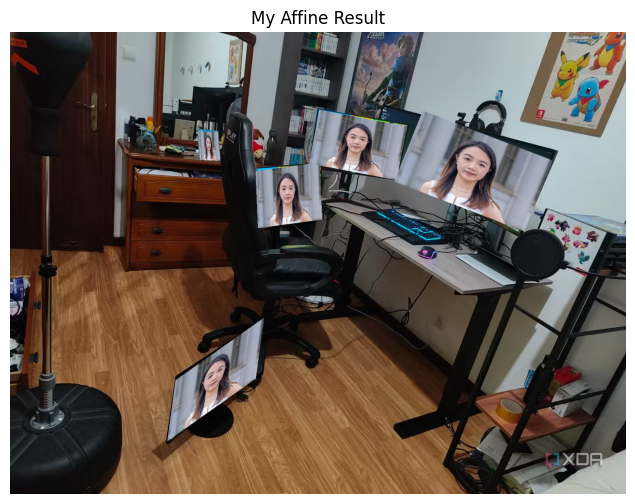

In [36]:
u_my = get_source_corners(my_source)

out_my_affine = my_target.copy()

for i in range(v_my.shape[1] // 4):
    v_i = v_my[:, i*4:(i+1)*4]
    H_aff = affine_solve(u_my, v_i)
    out_my_affine = paste_transformed(my_source, out_my_affine, H_aff)

plt.figure(figsize=(10, 6))
plt.imshow(out_my_affine)
plt.title("My Affine Result")
plt.axis("off")
plt.show()


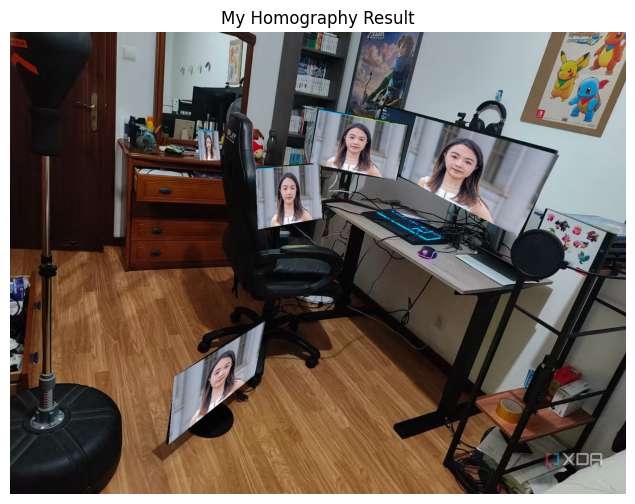

In [37]:
out_my_homo = my_target.copy()

for i in range(v_my.shape[1] // 4):
    v_i = v_my[:, i*4:(i+1)*4]
    H_h = homography_solve(u_my, v_i)
    out_my_homo = paste_transformed(my_source, out_my_homo, H_h)

plt.figure(figsize=(10, 6))
plt.imshow(out_my_homo)
plt.title("My Homography Result")
plt.axis("off")
plt.show()
